# kNN Predictors

*   Coded by DrQ
*   adapted two modes from L2 notebook



In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


# Boston Housing Dataset:


*  https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html
*  fea1: CRIM - per capita crime rate by town
*  fea14: MEDV - Median value of owner-occupied homes in $1000's
*  fea5: NOX - nitric oxides concentration (parts per 10 million)
*  fea6: RM - average number of rooms per dwelling








(506, 13)
(506,)
(506, 1)
(506,)


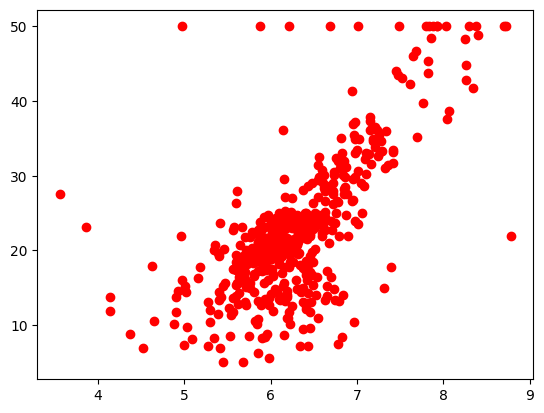

In [16]:
# Note: The request to show 'wrongly predicted samples by the above knn'
# likely refers to the KNeighborsClassifier used on the digits dataset (e.g., in cell _TKKLvDp_0Na).
# This cell (FCp_lBj9jHPk) loads the Boston housing dataset, which is for regression.
# Therefore, the requested classification-error visualization cannot be performed here.
# Please select the cell where the KNeighborsClassifier was trained and evaluated
# if you wish to visualize its misclassified samples.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

print(data.shape)

# Let's have a look at the last feature:
X = data[:, 5]
print(X.shape)
X = X.reshape(-1, 1)
print(X.shape)

#the boston housing data set, the targets to be predicted corresponds to the weighted distances to the five Boston employment centers.
y = target
print(y.shape)

plt.scatter(X, y,  color='red')

In [34]:
# import regressor
from sklearn.neighbors import KNeighborsRegressor
# instantiate with K=5
knn = KNeighborsRegressor(n_neighbors=8)
# fit with data
knn.fit(X, y)


KNeighborsRegressor(n_neighbors=8)

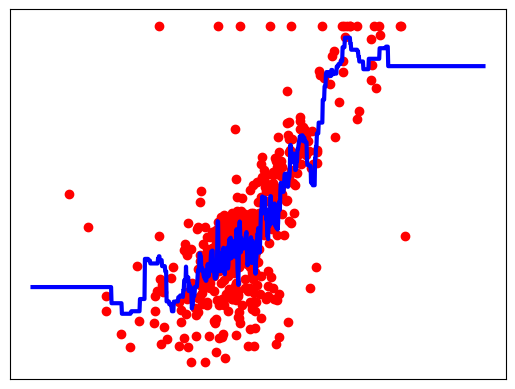

In [35]:
###
Xfit = np.linspace(3, 10, 1000).reshape(-1, 1)
yfit =knn.predict(Xfit)

# Plot outputs
plt.scatter(X, y,  color='red')
plt.plot(Xfit, yfit, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

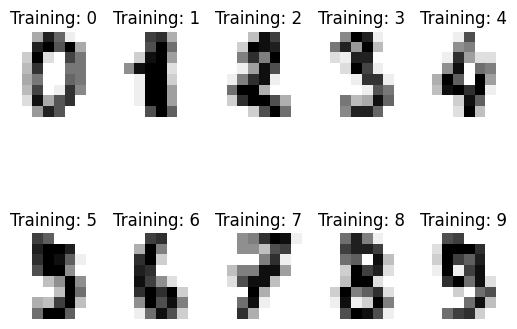

In [36]:
# Import datasets, classifiers and performance metrics
from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# The digits dataset
digits = datasets.load_digits()

_, axes = plt.subplots(2, 5)
images_and_labels = list(zip(digits.images, digits.target))
for ax, (image, label) in zip(axes[0, :], images_and_labels[:5]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Training: %i' % label)
for ax, (image, label) in zip(axes[1, :], images_and_labels[5:10]):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Training: %i' % label)


# To apply a classifier on this data, we need to flatten the image, to
# turn the data in a (samples, feature) matrix:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Split data into train and test subsets
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.5, shuffle=False)


Classification report for classifier KNeighborsClassifier(n_neighbors=3):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        88
           1       0.98      0.99      0.98        91
           2       0.99      0.94      0.96        86
           3       0.91      0.92      0.92        91
           4       0.99      0.93      0.96        92
           5       0.97      0.97      0.97        91
           6       0.99      1.00      0.99        91
           7       0.98      1.00      0.99        89
           8       0.94      0.95      0.95        88
           9       0.91      0.93      0.92        92

    accuracy                           0.96       899
   macro avg       0.96      0.96      0.96       899
weighted avg       0.96      0.96      0.96       899


Confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 90  0  0  0  0  0  0  1  0]
 [ 1  0 81  4  0  0  0  0  0  0]
 [ 0  0  0 84  0  1  0  2  3  1]
 [ 0  0  0  0 86

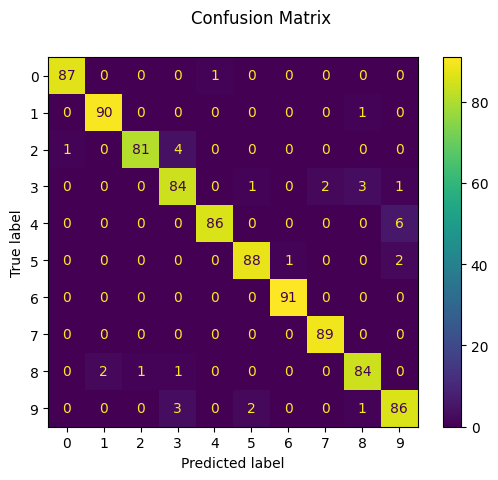

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay # Import ConfusionMatrixDisplay

# Create a classifier: kNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=3)

# We learn the digits on the first half of the digits
knn_classifier.fit(X_train, y_train)

# Now predict the value of the digit on the second half and store as predicted_knn:
predicted_knn = knn_classifier.predict(X_test)

print("Classification report for classifier %s:\n%s\n"
      % (knn_classifier, metrics.classification_report(y_test, predicted_knn)))

# Use ConfusionMatrixDisplay.from_estimator instead of metrics.plot_confusion_matrix
disp = ConfusionMatrixDisplay.from_estimator(knn_classifier, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")
print("Confusion matrix:\n%s" % disp.confusion_matrix)

plt.show()

Found 33 misclassified samples by kNN.


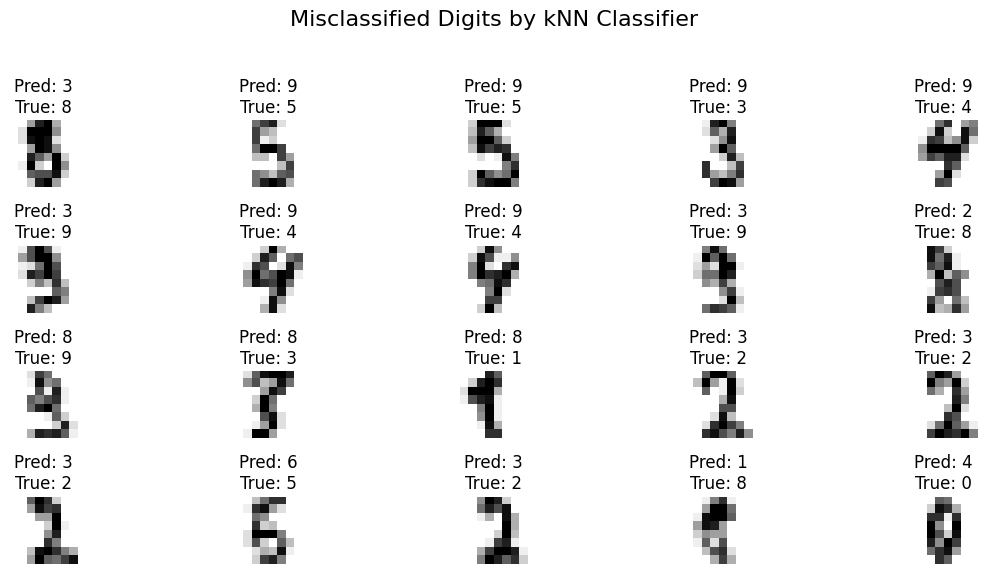

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Find misclassified samples for kNN
misclassified_indices_knn_plot = np.where(predicted_knn != y_test)[0]

print(f"Found {len(misclassified_indices_knn_plot)} misclassified samples by kNN.")

# Plot some of the misclassified samples
num_display_knn_plot = min(20, len(misclassified_indices_knn_plot)) # Display up to 20 misclassified samples

if num_display_knn_plot > 0:
    fig, axes = plt.subplots(int(np.ceil(num_display_knn_plot / 5)), 5, figsize=(12, 6))
    axes = axes.ravel()

    for i, bad_index in enumerate(misclassified_indices_knn_plot[:num_display_knn_plot]):
        image = X_test[bad_index].reshape(8, 8) # Reshape flattened data back to 8x8 image
        axes[i].imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        axes[i].set_title(f"Pred: {predicted_knn[bad_index]}\nTrue: {y_test[bad_index]}")
        axes[i].set_axis_off()

    plt.suptitle('Misclassified Digits by kNN Classifier', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("No misclassified samples by kNN to display.")

Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899


Confusion matrix:
[[87  0  0  0  1  0  0  0  0  0]
 [ 0 88  1  0  0  0  0  0  1  1]
 [ 0  0 85  1  0  0  0  0  0  0]
 [ 0  0  0 79  0  3  0  4  5  0]
 [ 0  0  0  0 88  0  0  0  0  4]
 [

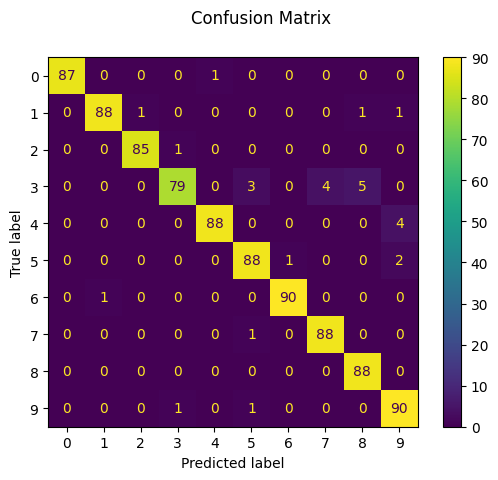

In [27]:
# Create a classifier: a support vector classifier
classifier = svm.SVC(gamma=0.001)

# We learn the digits on the first half of the digits
classifier.fit(X_train, y_train)

# Now predict the value of the digit on the second half:
predicted = classifier.predict(X_test)

print("Classification report for classifier %s:\n%s\n"
      % (classifier, metrics.classification_report(y_test, predicted)))

# Use ConfusionMatrixDisplay.from_estimator instead of metrics.plot_confusion_matrix
disp = metrics.ConfusionMatrixDisplay.from_estimator(classifier, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")
print("Confusion matrix:\n%s" % disp.confusion_matrix)

plt.show()

Found 28 misclassified samples by SVM.


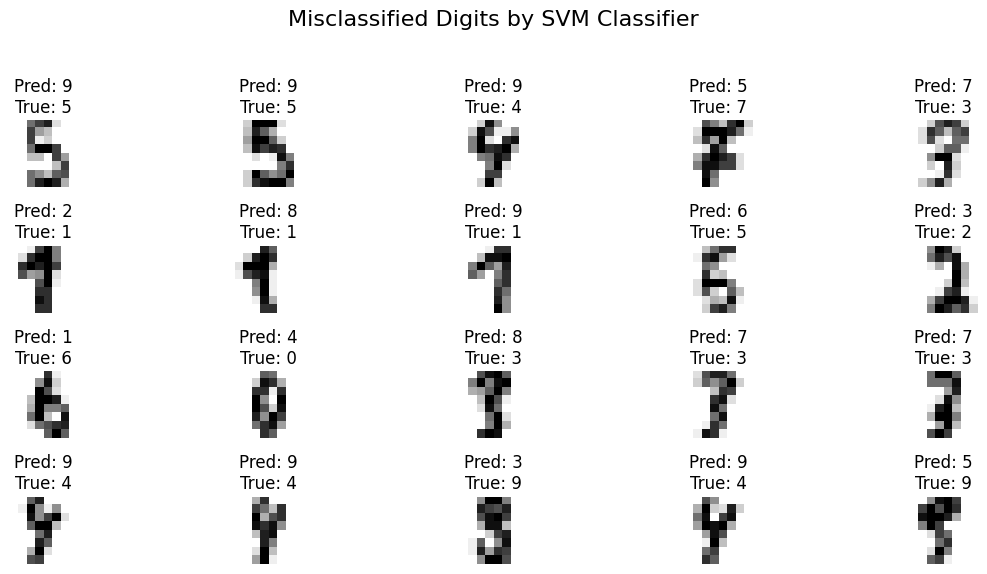

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Find misclassified samples for SVM
misclassified_indices_svm_plot = np.where(predicted != y_test)[0]

print(f"Found {len(misclassified_indices_svm_plot)} misclassified samples by SVM.")

# Plot some of the misclassified samples
num_display_svm_plot = min(20, len(misclassified_indices_svm_plot)) # Display up to 20 misclassified samples

if num_display_svm_plot > 0:
    fig_svm, axes_svm = plt.subplots(int(np.ceil(num_display_svm_plot / 5)), 5, figsize=(12, 6))
    axes_svm = axes_svm.ravel()

    for i, bad_index_svm in enumerate(misclassified_indices_svm_plot[:num_display_svm_plot]):
        image_svm = X_test[bad_index_svm].reshape(8, 8) # Reshape flattened data back to 8x8 image
        axes_svm[i].imshow(image_svm, cmap=plt.cm.gray_r, interpolation='nearest')
        axes_svm[i].set_title(f"Pred: {predicted[bad_index_svm]}\nTrue: {y_test[bad_index_svm]}")
        axes_svm[i].set_axis_off()

    plt.suptitle('Misclassified Digits by SVM Classifier', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("No misclassified samples by SVM to display.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure predicted_knn is available (from _TKKLvDp_0Na)
# Ensure predicted_svm is available (from lFrnxufx_fo0, assigned to 'predicted')
predicted_svm = predicted

# Define the plotting function for comparison categories
def plot_misclassified_category_comparison(indices, title_suffix, pred_source_knn=None, pred_source_svm=None, max_samples=5):
    if not indices:
        print(f"No samples in category: {title_suffix}")
        return

    num_display = min(max_samples, len(indices))
    if num_display == 0:
        print(f"No samples to display for category: {title_suffix}")
        return

    fig, axes = plt.subplots(1, num_display, figsize=(2 * num_display, 2))
    if num_display == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, bad_index in enumerate(indices[:num_display]):
        image = X_test[bad_index].reshape(8, 8)
        axes[i].imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')

        title_text = f"True: {y_test[bad_index]}"
        if pred_source_knn is not None:
            title_text += f"\nPred kNN: {pred_source_knn[bad_index]}"
        if pred_source_svm is not None:
            title_text += f"\nPred SVM: {pred_source_svm[bad_index]}"

        axes[i].set_title(title_text)
        axes[i].set_axis_off()

    fig.suptitle(f'Misclassified Samples {title_suffix}', fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


# Calculate and define the misclassified indices for comparison
misclassified_indices_knn = set(np.where(predicted_knn != y_test)[0])
misclassified_indices_svm = set(np.where(predicted_svm != y_test)[0])

misclassified_by_both = list(misclassified_indices_knn.intersection(misclassified_indices_svm))
knn_only_misclassified = list(misclassified_indices_knn.difference(misclassified_indices_svm))
svm_only_misclassified = list(misclassified_indices_svm.difference(misclassified_indices_knn))

print(f"Total samples misclassified by kNN: {len(misclassified_indices_knn)}")
print(f"Total samples misclassified by SVM: {len(misclassified_indices_svm)}")
print(f"Samples misclassified by both kNN and SVM: {len(misclassified_by_both)}")
print(f"Samples misclassified by kNN only: {len(knn_only_misclassified)}")
print(f"Samples misclassified by SVM only: {len(svm_only_misclassified)}")

print("\n--- Visualizing Comparison of Misclassified Samples ---")

# Now call the plotting functions for comparison
plot_misclassified_category_comparison(misclassified_by_both, "by Both kNN and SVM", predicted_knn, predicted_svm, max_samples=5)
plot_misclassified_category_comparison(knn_only_misclassified, "by kNN Only", predicted_knn, None, max_samples=5)
plot_misclassified_category_comparison(svm_only_misclassified, "by SVM Only", None, predicted_svm, max_samples=5)

In [43]:
# The 'predicted' variable from the last run (cell lFrnxufx_fo0) corresponds to SVM predictions
predicted_svm = predicted

misclassified_indices_knn = set(np.where(predicted_knn != y_test)[0])
misclassified_indices_svm = set(np.where(predicted_svm != y_test)[0])

misclassified_by_both = list(misclassified_indices_knn.intersection(misclassified_indices_svm))
knn_only_misclassified = list(misclassified_indices_knn.difference(misclassified_indices_svm))
svm_only_misclassified = list(misclassified_indices_svm.difference(misclassified_indices_knn))

print(f"Total samples misclassified by kNN: {len(misclassified_indices_knn)}")
print(f"Total samples misclassified by SVM: {len(misclassified_indices_svm)}")
print(f"Samples misclassified by both kNN and SVM: {len(misclassified_by_both)}")
print(f"Samples misclassified by kNN only: {len(knn_only_misclassified)}")
print(f"Samples misclassified by SVM only: {len(svm_only_misclassified)}")

Total samples misclassified by kNN: 33
Total samples misclassified by SVM: 28
Samples misclassified by both kNN and SVM: 16
Samples misclassified by kNN only: 17
Samples misclassified by SVM only: 12



--- Visualizing Misclassified Samples ---


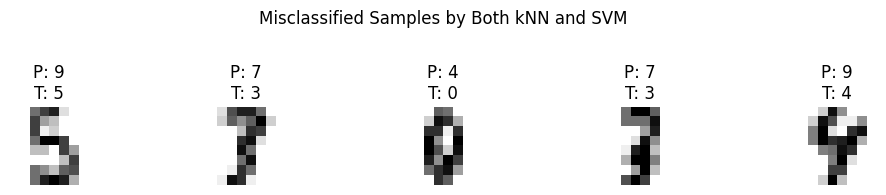

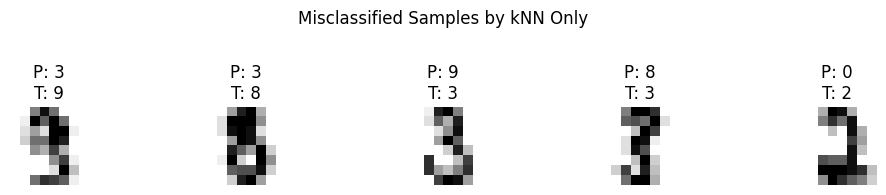

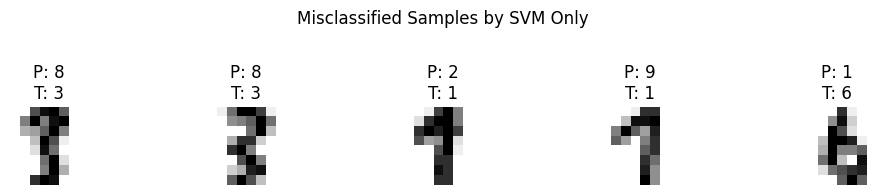

In [44]:
import matplotlib.pyplot as plt

def plot_misclassified_category(indices, title_suffix, pred_source, max_samples=5):
    if not indices:
        print(f"No samples in category: {title_suffix}")
        return

    num_display = min(max_samples, len(indices))
    if num_display == 0:
        print(f"No samples to display for category: {title_suffix}")
        return

    fig, axes = plt.subplots(1, num_display, figsize=(2 * num_display, 2))
    if num_display == 1:
        axes = [axes] # Ensure axes is iterable even for a single plot

    for i, bad_index in enumerate(indices[:num_display]):
        image = X_test[bad_index].reshape(8, 8)
        axes[i].imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        predicted_label = pred_source[bad_index] if pred_source is not None else 'N/A'
        axes[i].set_title(f"P: {predicted_label}\nT: {y_test[bad_index]}")
        axes[i].set_axis_off()

    fig.suptitle(f'Misclassified Samples {title_suffix}', fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


print("\n--- Visualizing Misclassified Samples ---")

plot_misclassified_category(misclassified_by_both, "by Both kNN and SVM", predicted_svm, max_samples=5)
plot_misclassified_category(knn_only_misclassified, "by kNN Only", predicted_knn, max_samples=5)
plot_misclassified_category(svm_only_misclassified, "by SVM Only", predicted_svm, max_samples=5)